<a href="https://colab.research.google.com/github/jceltruda/Projects-in-AI-and-ML/blob/main/Project_5/ML_AI_Projects_5_Graduate_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Unet Implementation

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
from datasets import load_dataset

# Load dataset
ds = load_dataset("Angelou0516/CVC-ClinicDB")

In [3]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

class HF_CVCClinicDataset(Dataset):
    def __init__(self, hf_split, transform=None):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        image = item['image'].convert("RGB")

        # The mask is 'label'
        mask_key = 'label' if 'label' in item else 'mask'
        mask = item[mask_key].convert("L") # Grayscale for the mask

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # Make the mask 0 or 1
        mask = (mask > 0.5).float()

        return image, mask

# Create datasets
train_dataset = HF_CVCClinicDataset(ds['train'], transform=transform)
val_dataset = HF_CVCClinicDataset(ds['validation'], transform=transform)

# Initialize loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Training samples: 490 | Validation samples: 61


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Decoder
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Down passes
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Up passes
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            # Edge case
            if x.shape != skip_connection.shape:
                x = transforms.functional.resize(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

model = UNet(in_channels=3, out_channels=1).to(device)

In [5]:
# Calculates dice coefficient
def dice_coeff(pred, target):
    smooth = 1e-5 # Prevents division by zero
    pred = torch.sigmoid(pred) > 0.5
    pred = pred.float()

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return dice

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 15

In [6]:
train_losses, val_losses = [], []
train_dices, val_dices = [], []

for epoch in range(epochs):
    model.train()
    train_loss, train_dice = 0, 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        # Forward pass
        predictions = model(images)
        loss = criterion(predictions, masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_coeff(predictions, masks).item()

    model.eval()
    val_loss, val_dice = 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            predictions = model(images)
            val_loss += criterion(predictions, masks).item()
            val_dice += dice_coeff(predictions, masks).item()

    # Calculate average metrics for the epoch
    avg_train_loss = train_loss / len(train_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Dice: {avg_train_dice:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

Epoch 1/15 | Train Loss: 0.4392 | Train Dice: 0.4415 | Val Loss: 0.3633 | Val Dice: 0.4311
Epoch 2/15 | Train Loss: 0.3320 | Train Dice: 0.5050 | Val Loss: 0.3146 | Val Dice: 0.4834
Epoch 3/15 | Train Loss: 0.2883 | Train Dice: 0.5993 | Val Loss: 0.2679 | Val Dice: 0.5705
Epoch 4/15 | Train Loss: 0.2697 | Train Dice: 0.6264 | Val Loss: 0.2823 | Val Dice: 0.5223
Epoch 5/15 | Train Loss: 0.2439 | Train Dice: 0.6526 | Val Loss: 0.2531 | Val Dice: 0.6128
Epoch 6/15 | Train Loss: 0.2185 | Train Dice: 0.7110 | Val Loss: 0.2183 | Val Dice: 0.6501
Epoch 7/15 | Train Loss: 0.2117 | Train Dice: 0.6976 | Val Loss: 0.1909 | Val Dice: 0.7000
Epoch 8/15 | Train Loss: 0.1859 | Train Dice: 0.7549 | Val Loss: 0.1945 | Val Dice: 0.6883
Epoch 9/15 | Train Loss: 0.1661 | Train Dice: 0.7900 | Val Loss: 0.1647 | Val Dice: 0.7349
Epoch 10/15 | Train Loss: 0.1540 | Train Dice: 0.8028 | Val Loss: 0.1947 | Val Dice: 0.6675
Epoch 11/15 | Train Loss: 0.1523 | Train Dice: 0.7827 | Val Loss: 0.1380 | Val Dice: 0.77

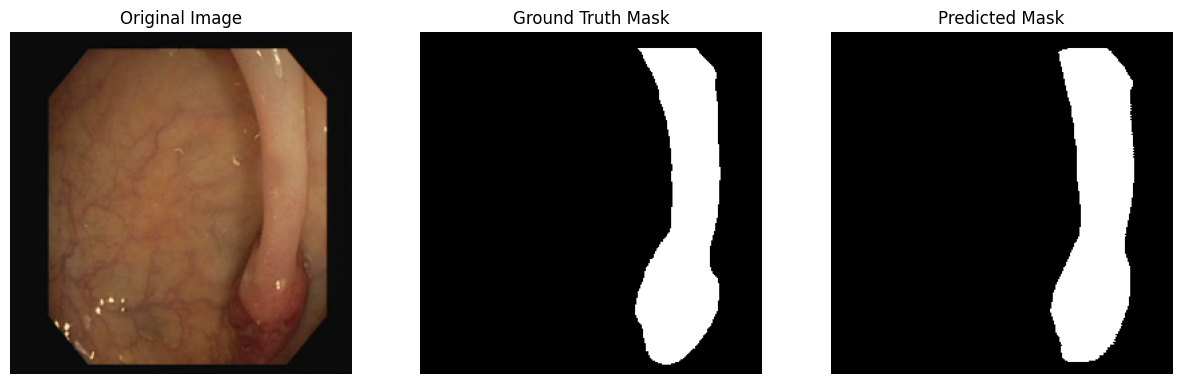

In [7]:
# Visualize a prediction
model.eval()
with torch.no_grad():
    image, mask = val_dataset[0]
    image_tensor = image.unsqueeze(0).to(device)

    pred = model(image_tensor)
    pred_mask = torch.sigmoid(pred) > 0.5

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(image.permute(1, 2, 0).cpu())
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask")
    plt.imshow(mask.squeeze().cpu(), cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask.squeeze().cpu(), cmap='gray')
    plt.axis('off')

    plt.show()

Two models I investigated are PraNet from "PraNet: Parallel Reverse Attention Network for Polyp Segmentation" in 2020, and Mobile-PolypNet from X in 2024. PraNet is a model which identifies polyps using high-level features via a parallel partial decoder, in order to create an initial global map. It then uses attention to find the edges of polyps. Mobile-PolypNet is a model which utilizes a encoder-decoder architecture, and uses residual blocks to achieve highly accurate polyp segmentation while drastically reducing the model's size and computational complexity.


Standard accuracy is not used to measure model performance because the majority of the image is always negative. Models are instead evaluated based on the portion of the positive tissue that their classification aligns with through a Dice score.

PraNet is a widely used model, which achieves a Dice score of about 0.899. Mobile-PolypNet achieves a score of 0.945. My model achieved a final validation Dice score of 0.812. My model was advanced enough to perform well, but didn't capture the full complexity of the task as well as these two models. The basic architecture could have benefitted from more complexity like in the other methods.